# part 4

Haikal Ali_1103223071_TK46GAB

# Chapter 4 — Vector Applications

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy import stats
import inspect

np.random.seed(0)

## 1. Correlation dan Cosine Similarity

Korelasi adalah angka tunggal yang mengukur hubungan linear antara dua variabel. Nilainya berada pada rentang -1 sampai +1:
- -1 berarti hubungan negatif sempurna.
- +1 berarti hubungan positif sempurna.
- 0 berarti tidak ada hubungan linear.

Dalam materi ini, korelasi Pearson dijelaskan sebagai dot product dari dua variabel yang sudah **mean-centered**, lalu dibagi dengan hasil kali norm kedua variabel.

Rumus korelasi Pearson:

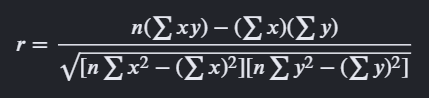

dengan syarat `x` dan `y` sudah dikurangi rata-ratanya.

Cosine similarity juga menggunakan dot product dan norm:

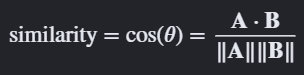

Perbedaan pentingnya: cosine similarity tidak melakukan mean-centering, sedangkan korelasi Pearson melakukan mean-centering.

### Exercise 4-1

Buat fungsi Python yang menerima dua vektor sebagai input dan menghasilkan dua angka:
1. Pearson correlation coefficient
2. Cosine similarity

Kode harus mengikuti formula dari materi, bukan langsung memakai `np.corrcoef` atau `spatial.distance.cosine`.

Cek bahwa hasil korelasi dan cosine similarity:
- sama ketika variabel sudah mean-centered,
- berbeda ketika variabel belum mean-centered.

In [2]:
def pearson_and_cosine(x, y):
  x = np.asarray(x)
  y = np.asarray(y)

  # Pearson correlation: mean-center dulu
  x_centered = x - np.mean(x)
  y_centered = y - np.mean(y)
  pearson = np.dot(x_centered, y_centered) / (
    np.linalg.norm(x_centered) * np.linalg.norm(y_centered)
  )

  # Cosine similarity: tanpa mean-centering
  cosine = np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

  return pearson, cosine


# Data belum mean-centered
x = np.array([0, 1, 2, 3])
y = np.array([100, 101, 102, 103])

pearson, cosine = pearson_and_cosine(x, y)
print("Data belum mean-centered")
print("Pearson correlation :", pearson)
print("Cosine similarity   :", cosine)

# Data sudah mean-centered
x_mc = x - np.mean(x)
y_mc = y - np.mean(y)

pearson_mc, cosine_mc = pearson_and_cosine(x_mc, y_mc)
print("\nData sudah mean-centered")
print("Pearson correlation :", pearson_mc)
print("Cosine similarity   :", cosine_mc)

Data belum mean-centered
Pearson correlation : 0.9999999999999998
Cosine similarity   : 0.8083174787557303

Data sudah mean-centered
Pearson correlation : 0.9999999999999998
Cosine similarity   : 0.9999999999999998


### Exercise 4-2

Buat variabel berisi bilangan 0 sampai 3. Buat variabel kedua yang sama dengan variabel pertama ditambah offset. Offset divariasikan dari -50 sampai +50.

Untuk setiap offset:
- hitung korelasi Pearson,
- hitung cosine similarity,
- simpan hasilnya,
- buat line plot seperti Figure 4-4.

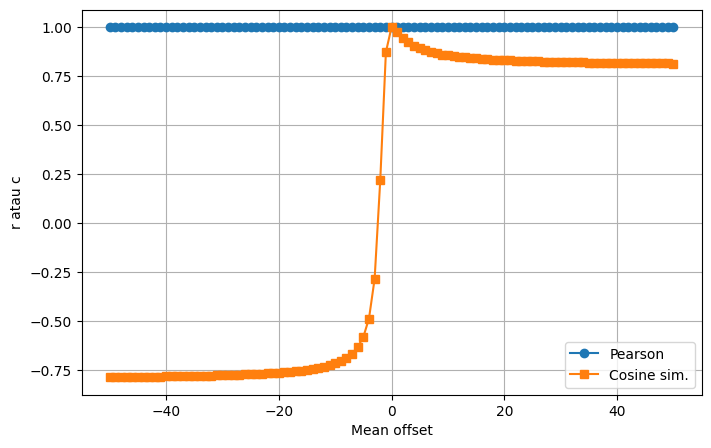

In [3]:
a = np.arange(4)
offsets = np.arange(-50, 51)

corrs = np.zeros(len(offsets))
cosines = np.zeros(len(offsets))

for i, offset in enumerate(offsets):
  b = a + offset
  corrs[i], cosines[i] = pearson_and_cosine(a, b)

plt.figure(figsize=(8, 5))
plt.plot(offsets, corrs, 'o-', label='Pearson')
plt.plot(offsets, cosines, 's-', label='Cosine sim.')
plt.xlabel('Mean offset')
plt.ylabel('r atau c')
plt.legend()
plt.grid(True)
plt.show()

### Exercise 4-3

Buka source code fungsi `pearsonr` dari `scipy.stats`, lalu pahami bagaimana implementasinya berhubungan dengan formula korelasi Pearson pada materi.

Kode di bawah menampilkan sebagian source code dari `stats.pearsonr`. Inti perhitungannya tetap sama: data dikurangi mean, lalu hubungan linear dihitung dari dot product yang dinormalisasi.

In [4]:
source_lines = inspect.getsource(stats.pearsonr).split('\n')

# Menampilkan sebagian source agar tidak terlalu panjang di notebook
for line in source_lines[:80]:
  print(line)

@xp_capabilities(cpu_only=True, exceptions=['cupy'],
                 jax_jit=False, allow_dask_compute=True)
def pearsonr(x, y, *, alternative='two-sided', method=None, axis=0):
    r"""
    Pearson correlation coefficient and p-value for testing non-correlation.

    The Pearson correlation coefficient [1]_ measures the linear relationship
    between two datasets. Like other correlation
    coefficients, this one varies between -1 and +1 with 0 implying no
    correlation. Correlations of -1 or +1 imply an exact linear relationship.
    Positive correlations imply that as x increases, so does y. Negative
    correlations imply that as x increases, y decreases.

    This function also performs a test of the null hypothesis that the
    distributions underlying the samples are uncorrelated and normally
    distributed. (See Kowalski [3]_
    for a discussion of the effects of non-normality of the input on the
    distribution of the correlation coefficient.)
    The p-value roughly in

### Exercise 4-4

Bandingkan waktu komputasi antara:
1. fungsi korelasi sederhana yang dibuat sendiri,
2. `np.corrcoef`.

Gunakan 1.000 iterasi. Pada setiap iterasi, buat dua vektor random berisi 500 angka, lalu hitung korelasinya.

In [5]:
def pearson_only(x, y):
  x = np.asarray(x)
  y = np.asarray(y)
  x = x - np.mean(x)
  y = y - np.mean(y)
  return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))


n_iter = 1000
n_data = 500

start = time.time()
for i in range(n_iter):
  x = np.random.randn(n_data)
  y = np.random.randn(n_data)
  r = pearson_only(x, y)
custom_time = time.time() - start

start = time.time()
for i in range(n_iter):
  x = np.random.randn(n_data)
  y = np.random.randn(n_data)
  r = np.corrcoef(x, y)[0, 1]
numpy_time = time.time() - start

print("Waktu fungsi sendiri :", custom_time)
print("Waktu np.corrcoef    :", numpy_time)
print("Rasio np.corrcoef / fungsi sendiri:", numpy_time / custom_time)

Waktu fungsi sendiri : 0.07101583480834961
Waktu np.corrcoef    : 0.126356840133667
Rasio np.corrcoef / fungsi sendiri: 1.7792769806151842


## 2. Time Series Filtering dan Feature Detection

Dot product juga digunakan pada filtering time series. Intinya, sebuah kernel pendek digeser sepanjang sinyal. Pada setiap posisi, kernel dikalikan dengan potongan sinyal yang panjangnya sama, lalu hasilnya dijumlahkan.

Prosedur ini menghasilkan sinyal baru yang menunjukkan seberapa cocok pola lokal pada sinyal dengan kernel.

### Exercise 4-5

Buat edge detector dengan kernel:

\[
[-1, +1]
\]

Kernel ini menghasilkan nilai 0 ketika sinyal datar, nilai positif ketika sinyal naik tajam, dan nilai negatif ketika sinyal turun tajam.

Langkah:
1. Buat kernel.
2. Buat sinyal plateau.
3. Geser kernel sepanjang sinyal.
4. Hitung dot product pada tiap posisi.
5. Plot kernel, sinyal, dan hasil edge detection seperti Figure 4-5.

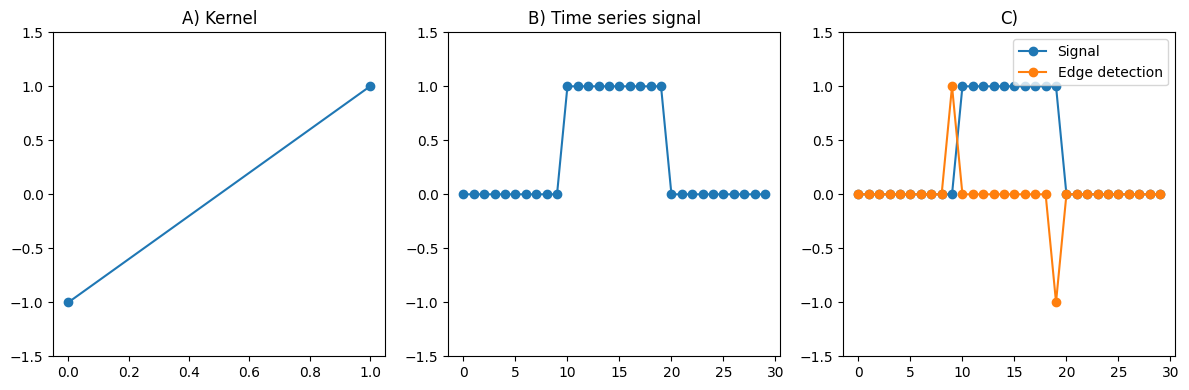

In [6]:
kernel = np.array([-1, 1])

signal = np.zeros(30)
signal[10:20] = 1

edge_detection = np.zeros_like(signal)

for i in range(len(signal) - len(kernel) + 1):
  segment = signal[i:i+len(kernel)]
  edge_detection[i] = np.dot(kernel, segment)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(kernel, 'o-')
plt.title('A) Kernel')
plt.ylim([-1.5, 1.5])

plt.subplot(1, 3, 2)
plt.plot(signal, 'o-')
plt.title('B) Time series signal')
plt.ylim([-1.5, 1.5])

plt.subplot(1, 3, 3)
plt.plot(signal, 'o-', label='Signal')
plt.plot(edge_detection, 'o-', label='Edge detection')
plt.title('C)')
plt.ylim([-1.5, 1.5])
plt.legend()

plt.tight_layout()
plt.show()

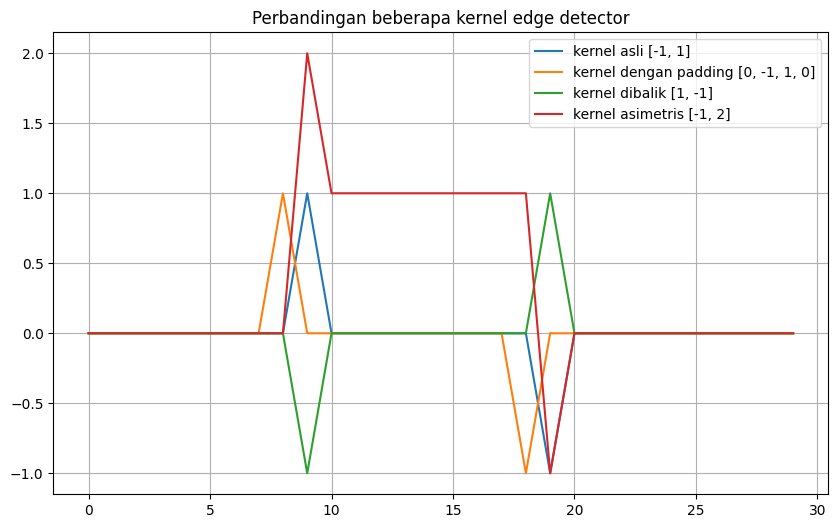

In [7]:
# Eksplorasi singkat sesuai pertanyaan pada exercise:
kernels_to_test = {
  "kernel asli [-1, 1]": np.array([-1, 1]),
  "kernel dengan padding [0, -1, 1, 0]": np.array([0, -1, 1, 0]),
  "kernel dibalik [1, -1]": np.array([1, -1]),
  "kernel asimetris [-1, 2]": np.array([-1, 2])
}

plt.figure(figsize=(10, 6))

for name, k in kernels_to_test.items():
  output = np.zeros_like(signal)
  for i in range(len(signal) - len(k) + 1):
    segment = signal[i:i+len(k)]
    output[i] = np.dot(k, segment)
  plt.plot(output, label=name)

plt.title('Perbandingan beberapa kernel edge detector')
plt.legend()
plt.grid(True)
plt.show()

### Exercise 4-6

Ulangi prosedur filtering, tetapi dengan:
- sinyal berisi 100 angka random dari distribusi Gaussian,
- kernel berbentuk bell-shaped:

\[
[0, .1, .3, .8, 1, .8, .3, .1, 0]
\]

Kernel harus dinormalisasi sehingga jumlahnya 1. Hasil filtering menjadi sinyal yang lebih halus atau low-pass filtering.

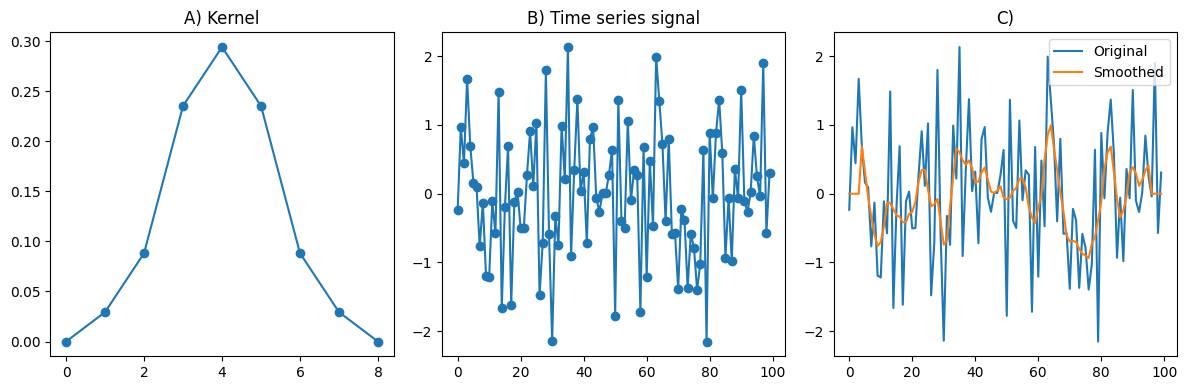

In [8]:
signal = np.random.randn(100)

kernel = np.array([0, .1, .3, .8, 1, .8, .3, .1, 0])
kernel = kernel / np.sum(kernel)

half_k = len(kernel) // 2
filtered = np.zeros_like(signal)

for i in range(half_k, len(signal) - half_k):
  segment = signal[i-half_k:i+half_k+1]
  filtered[i] = np.dot(kernel, segment)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(kernel, 'o-')
plt.title('A) Kernel')

plt.subplot(1, 3, 2)
plt.plot(signal, 'o-')
plt.title('B) Time series signal')

plt.subplot(1, 3, 3)
plt.plot(signal, label='Original')
plt.plot(filtered, label='Smoothed')
plt.title('C)')
plt.legend()

plt.tight_layout()
plt.show()

### Exercise 4-7

Ganti nilai tengah kernel dari 1 menjadi -1, lalu mean-center kernel. Jalankan kembali kode filtering.

Hasilnya bukan smoothing, tetapi menonjolkan perubahan tajam pada sinyal. Ini disebut high-pass filter.

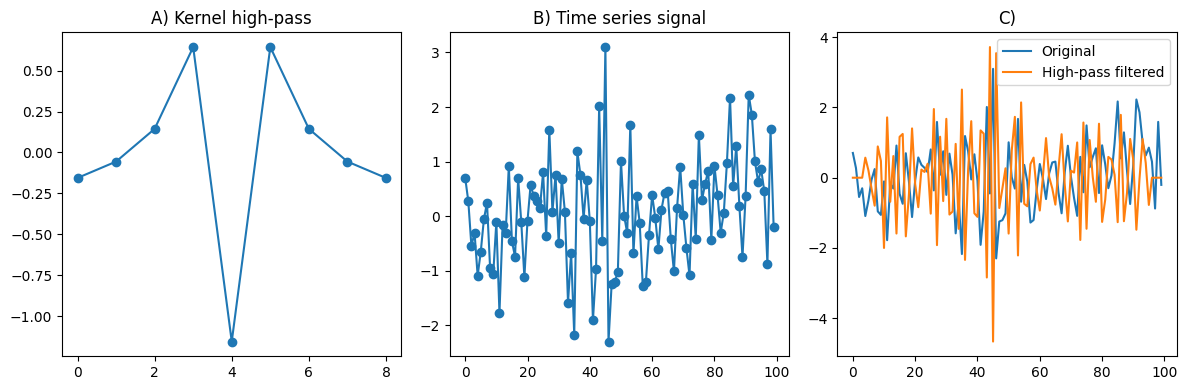

In [9]:
signal = np.random.randn(100)

kernel = np.array([0, .1, .3, .8, -1, .8, .3, .1, 0])
kernel = kernel - np.mean(kernel)

half_k = len(kernel) // 2
filtered = np.zeros_like(signal)

for i in range(half_k, len(signal) - half_k):
  segment = signal[i-half_k:i+half_k+1]
  filtered[i] = np.dot(kernel, segment)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(kernel, 'o-')
plt.title('A) Kernel high-pass')

plt.subplot(1, 3, 2)
plt.plot(signal, 'o-')
plt.title('B) Time series signal')

plt.subplot(1, 3, 3)
plt.plot(signal, label='Original')
plt.plot(filtered, label='High-pass filtered')
plt.title('C)')
plt.legend()

plt.tight_layout()
plt.show()

## 3. k-Means Clustering

k-means clustering adalah metode unsupervised untuk mengelompokkan data multivariat ke dalam beberapa kelompok berdasarkan jarak ke pusat kelompok.

Algoritma sederhana k-means:
1. Inisialisasi `k` centroid secara acak dari ruang data.
2. Hitung jarak setiap data ke setiap centroid.
3. Masukkan setiap data ke kelompok dengan centroid terdekat.
4. Update centroid sebagai rata-rata semua data pada kelompok tersebut.
5. Ulangi langkah 2–4 sampai kriteria berhenti terpenuhi atau sampai jumlah iterasi tertentu.

Materi menggunakan `k = 3` dan data acak 2D.

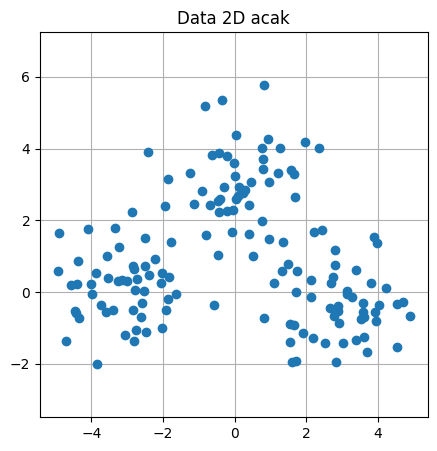

In [10]:
# Membuat data acak 2D untuk demonstrasi k-means
n_per_cluster = 50

data1 = np.random.randn(n_per_cluster, 2) + np.array([-3, 0])
data2 = np.random.randn(n_per_cluster, 2) + np.array([0, 3])
data3 = np.random.randn(n_per_cluster, 2) + np.array([3, 0])

data = np.vstack((data1, data2, data3))

plt.figure(figsize=(5, 5))
plt.plot(data[:, 0], data[:, 1], 'o')
plt.title('Data 2D acak')
plt.axis('equal')
plt.grid(True)
plt.show()

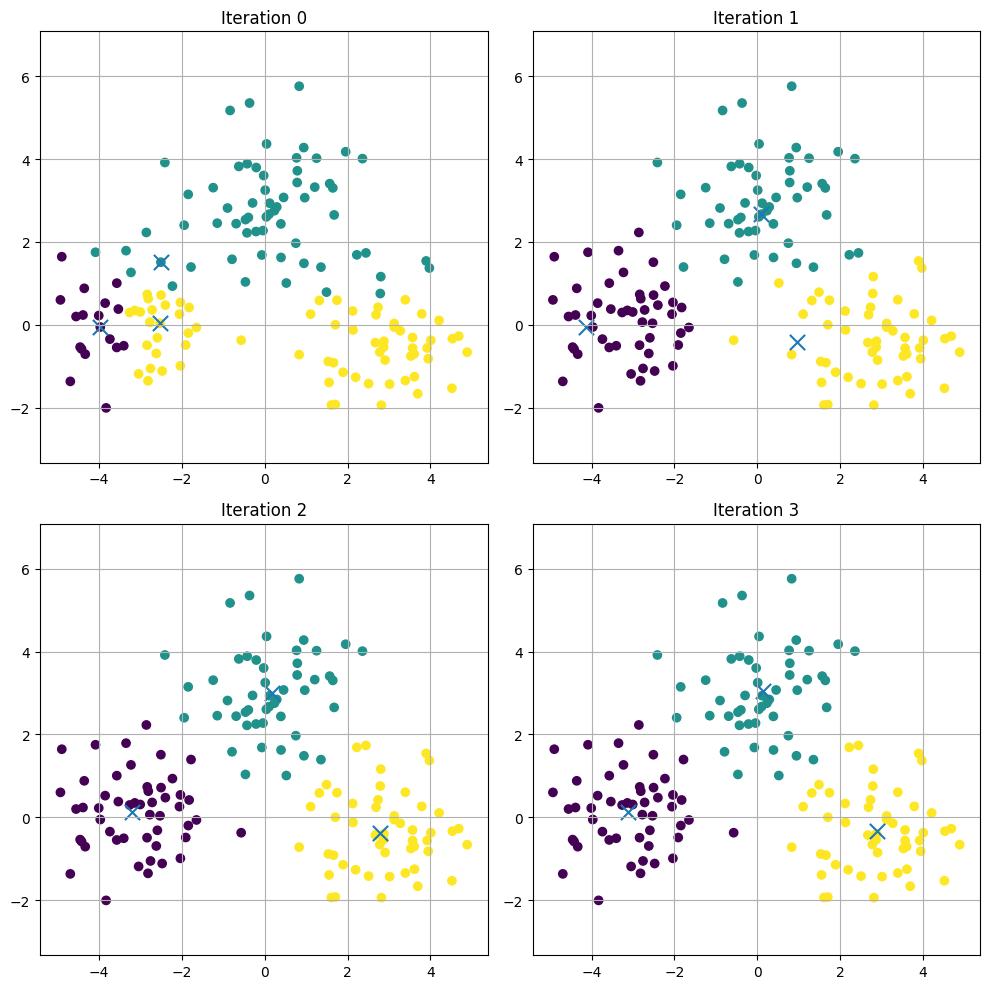

In [11]:
def run_kmeans(data, k=3, n_iter=3):
  ridx = np.random.choice(range(len(data)), k, replace=False)
  centroids = data[ridx, :].copy()

  history = []
  groupidx = None

  for iteration in range(n_iter + 1):
    dists = np.zeros((data.shape[0], k))

    for ci in range(k):
      dists[:, ci] = np.sum((data - centroids[ci, :])**2, axis=1)

    groupidx = np.argmin(dists, axis=1)

    history.append((centroids.copy(), groupidx.copy()))

    if iteration < n_iter:
      for ki in range(k):
        if np.any(groupidx == ki):
          centroids[ki, :] = [
            np.mean(data[groupidx == ki, 0]),
            np.mean(data[groupidx == ki, 1])
          ]

  return history


history = run_kmeans(data, k=3, n_iter=3)

plt.figure(figsize=(10, 10))

for i, (centroids, groupidx) in enumerate(history):
  plt.subplot(2, 2, i + 1)
  plt.scatter(data[:, 0], data[:, 1], c=groupidx)
  plt.scatter(centroids[:, 0], centroids[:, 1], s=120, marker='x')
  plt.title(f'Iteration {i}')
  plt.axis('equal')
  plt.grid(True)

plt.tight_layout()
plt.show()

### Exercise 4-8

Ulangi k-means beberapa kali dengan `k = 3` tanpa membuat data baru. Bandingkan hasil akhir clustering secara visual. Tujuannya adalah melihat apakah hasil akhirnya cenderung mirip walaupun centroid awal dipilih secara acak.

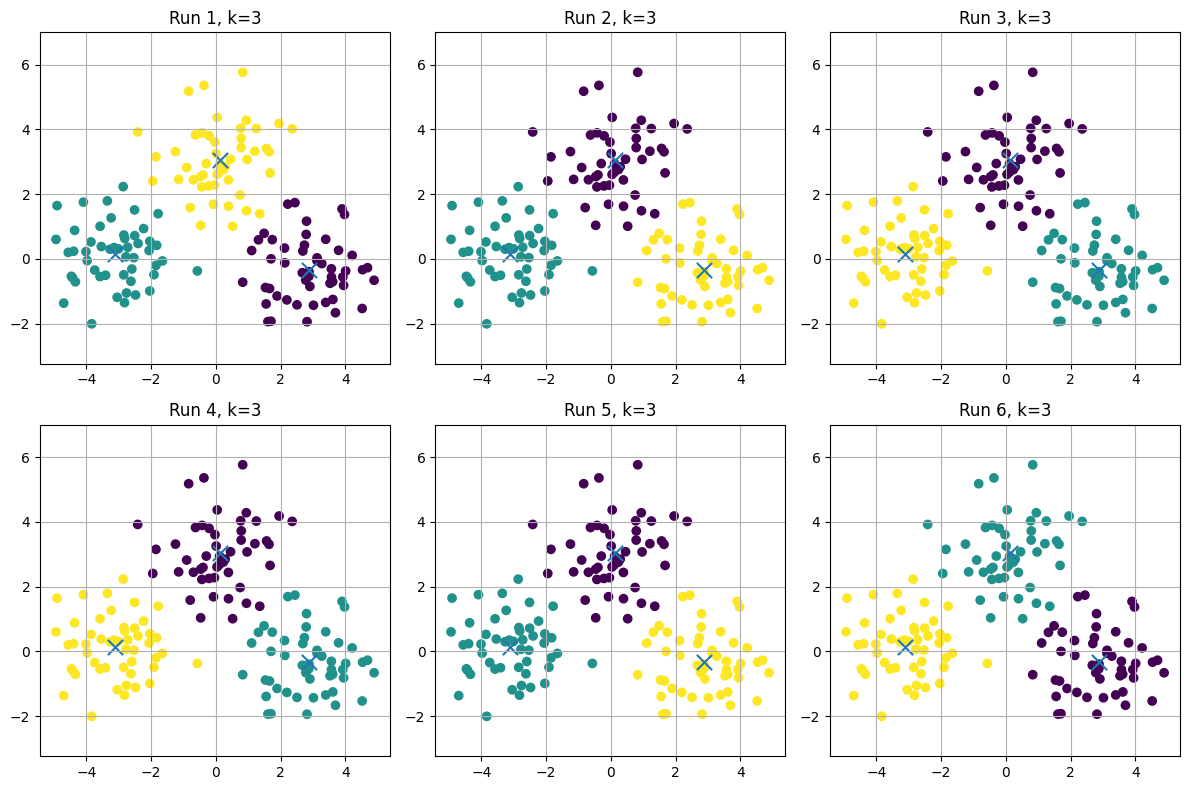

In [12]:
def plot_multiple_kmeans(data, k, runs=6, n_iter=10):
  plt.figure(figsize=(12, 8))

  for run in range(runs):
    history = run_kmeans(data, k=k, n_iter=n_iter)
    centroids, groupidx = history[-1]

    plt.subplot(2, 3, run + 1)
    plt.scatter(data[:, 0], data[:, 1], c=groupidx)
    plt.scatter(centroids[:, 0], centroids[:, 1], s=120, marker='x')
    plt.title(f'Run {run+1}, k={k}')
    plt.axis('equal')
    plt.grid(True)

  plt.tight_layout()
  plt.show()


plot_multiple_kmeans(data, k=3, runs=6, n_iter=10)

Berdasarkan visualisasi beberapa run dengan `k = 3`, hasil akhir umumnya mirip karena data memang memiliki tiga kelompok utama. Perbedaan bisa muncul karena centroid awal dipilih acak.

### Exercise 4-9

Ulangi beberapa clustering menggunakan `k = 2` dan `k = 4`, lalu nilai hasilnya secara visual.

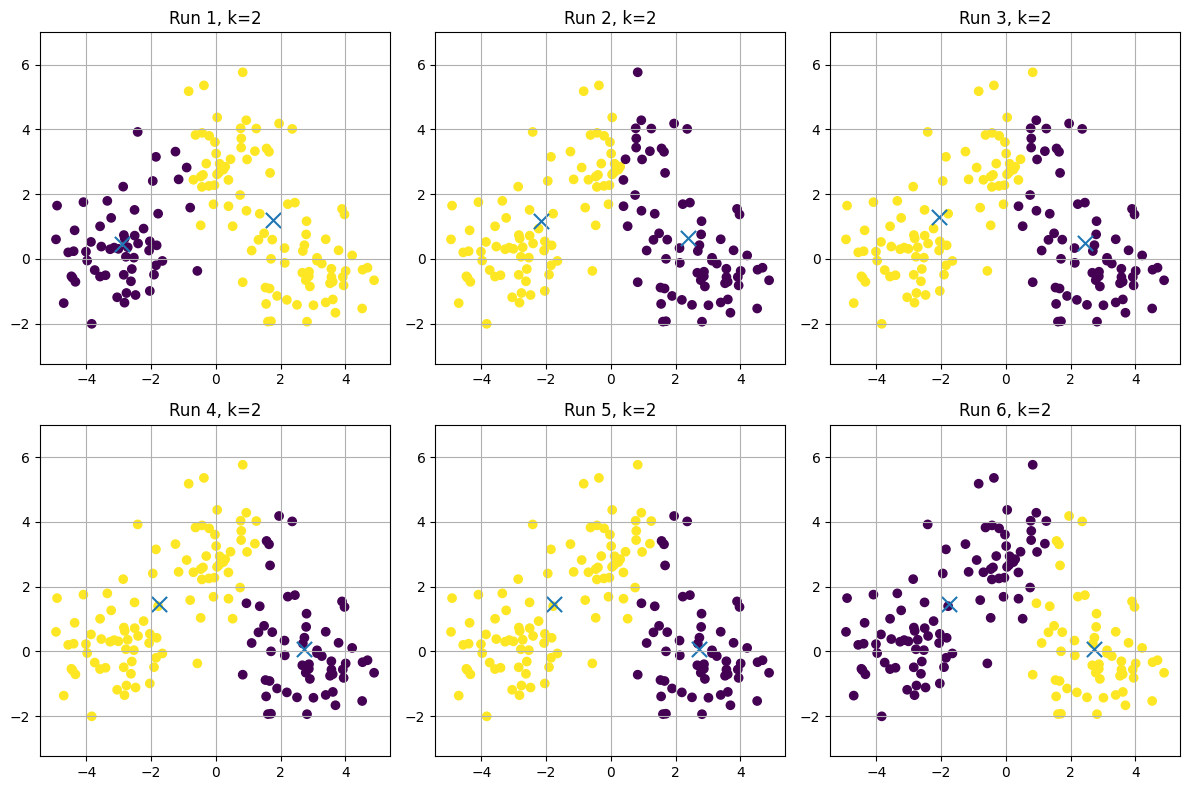

In [13]:
plot_multiple_kmeans(data, k=2, runs=6, n_iter=10)

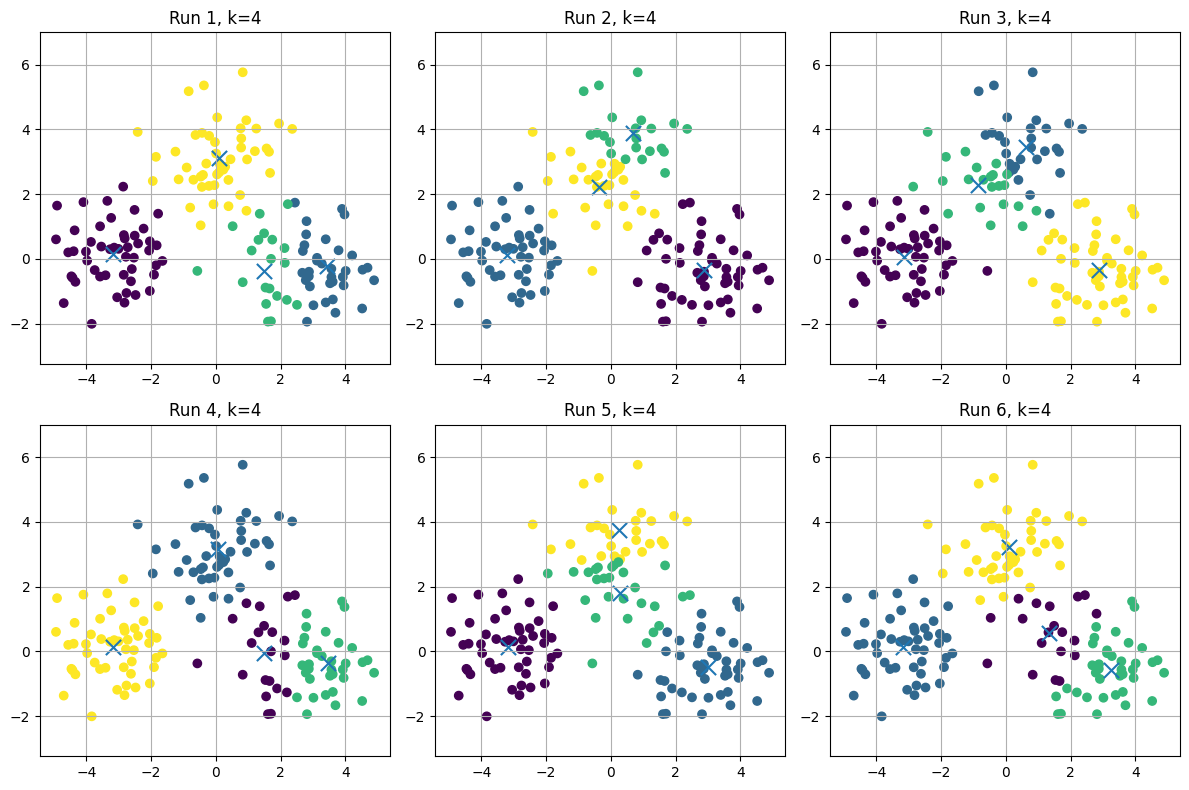

In [14]:
plot_multiple_kmeans(data, k=4, runs=6, n_iter=10)

Dengan `k = 2`, sebagian kelompok yang seharusnya terpisah akan digabung.  
Dengan `k = 4`, salah satu kelompok utama cenderung terpecah menjadi dua.  
Untuk data acak 2D yang dibuat di sini, `k = 3` paling sesuai dengan struktur data.

## Ringkasan

Bab ini menunjukkan beberapa aplikasi operasi vektor:
- Korelasi Pearson dan cosine similarity dibangun dari dot product dan norm.
- Filtering time series menggunakan dot product antara kernel dan potongan sinyal.
- k-means clustering menggunakan jarak Euclidean, norm, dan broadcasting untuk mengelompokkan data.